# Social Impact of AI
## Module 5, Lesson 5

In this notebook, we will:
1. Estimate the carbon footprint of training ML models
2. Simulate the effect of automation on a hypothetical workforce
3. Analyze the amplification of misinformation through recommendation algorithms
4. Visualize the distribution of AI benefits across populations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Estimating Carbon Footprint of ML Models

We compare the estimated CO2 emissions of training different model sizes, based on Strubell et al. (2019).

In [2]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (100 trees)', 'BERT Base', 'BERT Large', 'GPT-3'],
    'Parameters': [1e3, 1e6, 1.1e8, 3.4e8, 1.75e11],
    'Training_Hours': [0.01, 0.5, 168, 336, 5040],
    'GPU_Count': [0, 0, 64, 64, 10000],
    'GPU_Power_W': [0, 0, 300, 300, 400],
    'PUE': [1.0, 1.0, 1.2, 1.2, 1.3]  # Power Usage Effectiveness
})

# CO2 emission factor: 0.5 kg CO2 per kWh (global average)
CO2_PER_KWH = 0.5  # kg

def estimate_co2(row):
    if row['GPU_Count'] == 0:
        return 0.001  # negligible
    kwh = row['GPU_Count'] * row['GPU_Power_W'] / 1000 * row['Training_Hours'] * row['PUE']
    co2_kg = kwh * CO2_PER_KWH
    return co2_kg / 1000  # convert to metric tons

models['Estimated_CO2_tons'] = models.apply(estimate_co2, axis=1)

models['Equivalent'] = [
    '< 1 kg',
    '< 1 kg',
    '1 round-trip flight NYC-SF',
    '~5 cars driven for a year',
    '~500 cars driven for a year'
]

print("Estimated CO2 Emissions for Training ML Models:")
print(models[['Model', 'Parameters', 'Estimated_CO2_tons', 'Equivalent']].to_string(index=False))

Estimated CO2 Emissions for Training ML Models:
                    Model   Parameters  Estimated_CO2_tons                  Equivalent
      Logistic Regression 1.000000e+03             0.00100                      < 1 kg
Random Forest (100 trees) 1.000000e+06             0.00100                      < 1 kg
                BERT Base 1.100000e+08             1.93536  1 round-trip flight NYC-SF
               BERT Large 3.400000e+08             3.87072   ~5 cars driven for a year
                    GPT-3 1.750000e+11         13104.00000 ~500 cars driven for a year


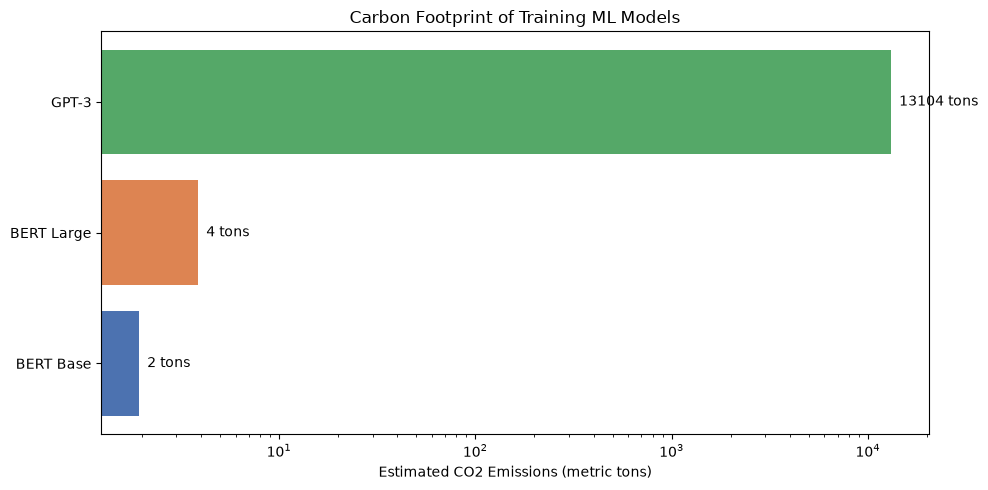

In [3]:
plt.figure(figsize=(10, 5))
models_plot = models[models['Estimated_CO2_tons'] > 0.01]
bars = plt.barh(models_plot['Model'], models_plot['Estimated_CO2_tons'], color=['#4C72B0', '#DD8452', '#55A868'])
plt.xlabel('Estimated CO2 Emissions (metric tons)')
plt.title('Carbon Footprint of Training ML Models')
plt.xscale('log')
for bar, val in zip(bars, models_plot['Estimated_CO2_tons']):
    plt.text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2, f'{val:.0f} tons', va='center')
plt.tight_layout()
plt.show()

## 2. Simulating Automation Impact on Employment

We simulate a hypothetical workforce and model the impact of AI automation over time.

In [4]:
years = np.arange(2024, 2044)
n_years = len(years)

# Job categories and automation risk
categories = ['Routine Manual', 'Routine Cognitive', 'Creative', 'Social/Emotional', 'Technical/Expert']
automation_risk = [0.8, 0.6, 0.15, 0.1, 0.3]  # Probability of automation by 2040
initial_workers = [100, 150, 80, 120, 50]

# Simple logistic model of automation adoption
def adoption_curve(t, risk, t0=2032, rate=0.3):
    return risk / (1 + np.exp(-rate * (t - t0)))

employment = pd.DataFrame({'Year': years})
for i, cat in enumerate(categories):
    adoption_rate = adoption_curve(years, automation_risk[i])
    workers = initial_workers[i] * (1 - adoption_rate)
    employment[cat] = workers

employment['Total'] = employment[categories].sum(axis=1)

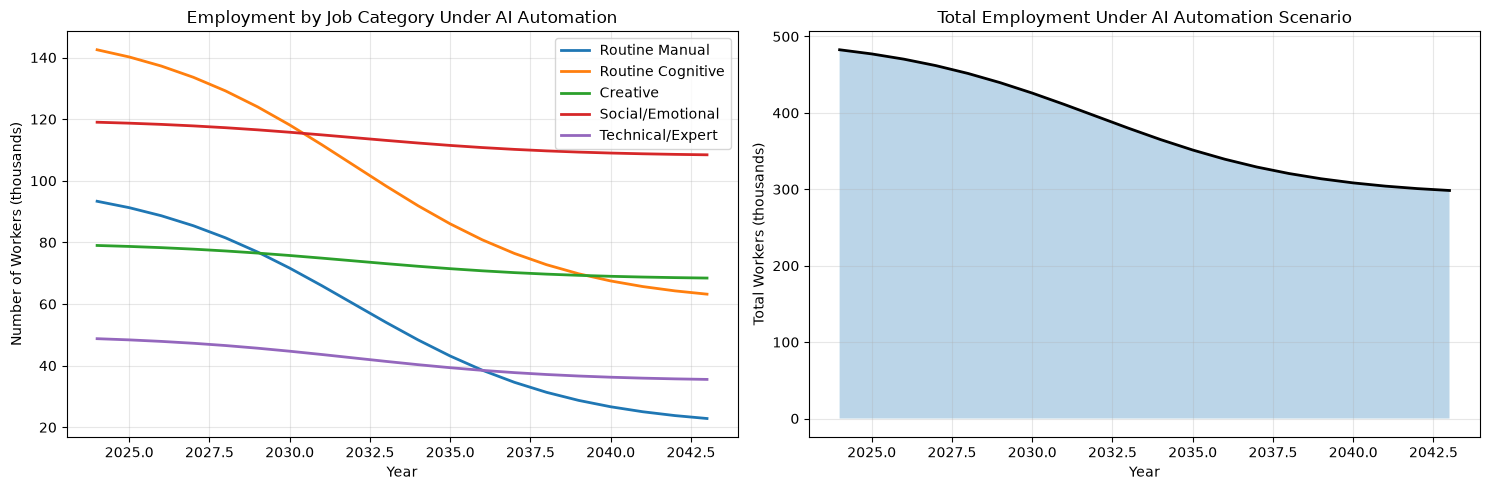

Employment change 2024-2044:
  Routine Manual: 71K jobs lost
  Creative: 11K jobs lost
  Social/Emotional: 11K jobs lost
  Total change: 184K workers

Note: This is a simplified simulation. Real impacts depend on policy, retraining, and new job creation.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Employment by category over time
for cat in categories:
    axes[0].plot(employment['Year'], employment[cat], label=cat, linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Workers (thousands)')
axes[0].set_title('Employment by Job Category Under AI Automation')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Total employment
axes[1].plot(employment['Year'], employment['Total'], 'k-', linewidth=2)
axes[1].fill_between(employment['Year'], employment['Total'], alpha=0.3)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Workers (thousands)')
axes[1].set_title('Total Employment Under AI Automation Scenario')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Employment change 2024-2044:")
print(f"  Routine Manual: {employment.iloc[0, 1] - employment.iloc[-1, 1]:.0f}K jobs lost")
print(f"  Creative: {employment.iloc[0, 3] - employment.iloc[-1, 3]:.0f}K jobs lost")
print(f"  Social/Emotional: {employment.iloc[0, 4] - employment.iloc[-1, 4]:.0f}K jobs lost")
print(f"  Total change: {employment.iloc[0, -1] - employment.iloc[-1, -1]:.0f}K workers")
print("\nNote: This is a simplified simulation. Real impacts depend on policy, retraining, and new job creation.")

## 3. Misinformation Amplification Simulation

We simulate how a recommendation algorithm can amplify misinformation based on engagement metrics.

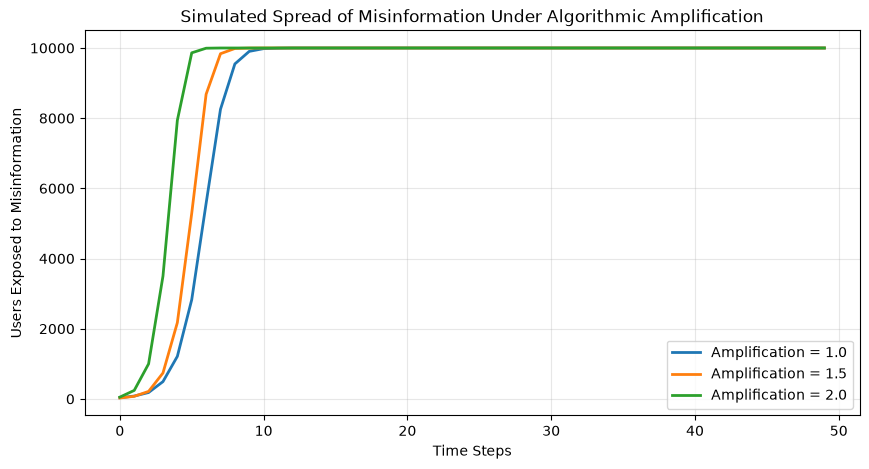

The amplification factor simulates how recommendation algorithms prioritizing high-engagement content can accelerate misinformation spread.


In [6]:
def simulate_misinformation_spread(n_users=10000, n_steps=50, amplification_factor=1.0):
    # Initialize: a small fraction of users share misinformation
    exposed = np.zeros(n_users, dtype=bool)
    initial_seed = 10
    exposed[:initial_seed] = True
    
    # Social network: random connections
    connections = np.random.randint(1, 50, size=n_users)
    
    history = []
    for step in range(n_steps):
        # Each exposed user influences their connections
        new_exposed = exposed.copy()
        for i in range(n_users):
            if exposed[i]:
                # Probability of spreading = amplification_factor * (connections[i] / 50)
                spread_prob = amplification_factor * (connections[i] / 50) * 0.1
                for _ in range(int(connections[i])):
                    target = np.random.randint(n_users)
                    if np.random.random() < spread_prob:
                        new_exposed[target] = True
        exposed = new_exposed
        history.append(exposed.sum())
    
    return history

plt.figure(figsize=(10, 5))
for amp in [1.0, 1.5, 2.0]:
    h = simulate_misinformation_spread(amplification_factor=amp)
    plt.plot(h, label=f'Amplification = {amp}', linewidth=2)

plt.xlabel('Time Steps')
plt.ylabel('Users Exposed to Misinformation')
plt.title('Simulated Spread of Misinformation Under Algorithmic Amplification')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("The amplification factor simulates how recommendation algorithms prioritizing high-engagement content can accelerate misinformation spread.")

## 4. Exercises

### Basic
1. Based on the carbon footprint data, about how much more CO2 does GPT-3 produce compared to BERT Base? What causes this difference?
2. In the automation simulation, which job category is most affected? Why?

### Analysis
3. Modify the automation simulation to include a "new job creation" parameter. What level of new job creation would be needed to keep total employment constant?
4. In the misinformation simulation, what happens if you reduce the amplification factor to 0.5? What does this represent in real-world terms?

### Critical Thinking
5. The carbon footprint estimates in this notebook are simplified. What factors are not included? How would including them change the estimates?
6. Design a policy intervention that could mitigate the employment effects of AI automation. Be specific about what the policy would do, who would implement it, and how it would be funded.
7. Should AI companies be required to report the carbon footprint of their models? Should there be a carbon tax on AI training runs?